<a href="https://colab.research.google.com/github/sharmaakshita9716-commits/HR_Performance_Analytics/blob/main/HR_Performance_Attrition_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**HR Analytics: Employee Performance & Attrition Analysis**

*Project Overview*:

This project aims to help HR departments understand "why employees leave"
and "what drives high performance".By analyzing employee data ,we
can build a predictive model to identify "at-risk" talent and top
performers.

Objective:



1.   Identify key factors leading to employee turnover.
2.    Analyze the relationship between work-life balance and performance.


*  Build a machine Learning model to predict future attrition.




**Data Collection**

We are using the "IBM HR Analytics Dataset".This dataset contains information on 1,470 employeees , including their backgrounds, job roles, and whether they stayed or left the company.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/content/HR_Employee_Attrition_Full_Dataset (2).csv')
display(df.head())

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
num_employees = df.shape[0]
print(f"The dataset contains {num_employees} employees.")

The dataset contains 1470 employees.


In [9]:
df.sample(20)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
942,36,No,Travel_Rarely,325,Research & Development,10,4,Technical Degree,1,1312,...,1,80,0,10,0,3,7,7,1,7
188,34,No,Travel_Frequently,1069,Research & Development,2,1,Life Sciences,1,256,...,3,80,0,10,2,2,10,9,1,9
1147,49,No,Travel_Rarely,722,Research & Development,25,4,Life Sciences,1,1617,...,4,80,1,10,3,2,9,6,1,4
632,42,No,Travel_Frequently,1271,Research & Development,2,1,Medical,1,875,...,4,80,0,8,2,3,2,1,2,2
864,41,Yes,Non-Travel,906,Research & Development,5,2,Life Sciences,1,1210,...,1,80,1,5,2,1,1,0,0,0
943,46,No,Travel_Rarely,991,Human Resources,1,2,Life Sciences,1,1314,...,3,80,0,10,3,4,7,6,5,7
964,34,No,Travel_Rarely,507,Sales,15,2,Medical,1,1356,...,4,80,0,10,6,4,10,8,9,6
1006,49,Yes,Travel_Frequently,1475,Research & Development,28,2,Life Sciences,1,1420,...,1,80,0,20,2,3,4,3,1,3
1211,37,No,Travel_Frequently,1278,Sales,1,4,Medical,1,1700,...,3,80,2,6,2,2,6,3,1,3
90,40,No,Travel_Frequently,530,Research & Development,1,4,Life Sciences,1,119,...,4,80,1,22,3,2,22,3,11,11


*Exploratory Data Analysis*

In this section, we explore the key factors affecting "Attrition" and "performance".We want to see which departments or job roles are most at risk.

Attrition.Counts
Attrition
No     1233
Yes     237
Name: count, dtype: int64


/tmp/ipykernel_1438/1572477976.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='Attrition',palette='viridis')


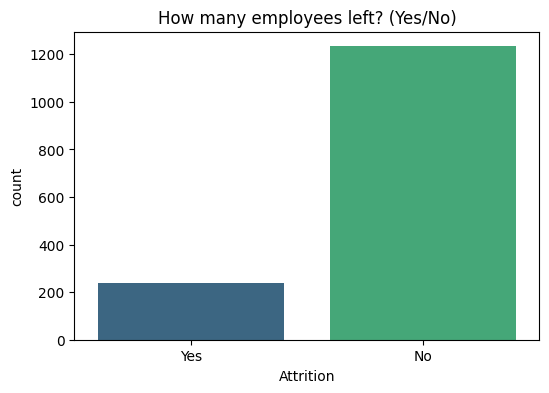

In [11]:
print("Attrition.Counts")
print(df['Attrition'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df,x='Attrition',palette='viridis')
plt.title('How many employees left? (Yes/No)')
plt.show()

Insight:

High Retention Base:

With 1,233 employees staying, the company has a strong stable core. However, the 237 who left represent a significant loss of institutional knowledge.

Business Meaning:

Replacing these 237 people involves high "Replacement costs".We need to identify if these are "Regrettable losses" (high performers) or "Non-regrettable losses".

/tmp/ipykernel_1438/3242501272.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='PerformanceRating',palette='magma')


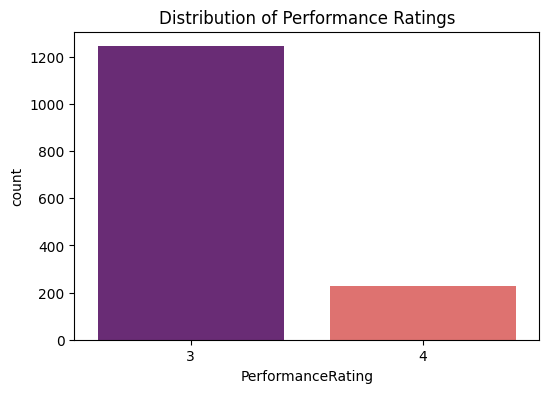

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='PerformanceRating',palette='magma')
plt.title("Distribution of Performance Ratings")
plt.show()

Insights:

Standardized Excellence:

Over 1,200 employees are rated as"3" , showing that the majority of the workforce meets high performance standards.

Business Meaning:

Only about 15% of employees  reach a level of "4". This suggests company has strict criteria for top ratings,which helps in identifying truly exceptional talent for promotions.



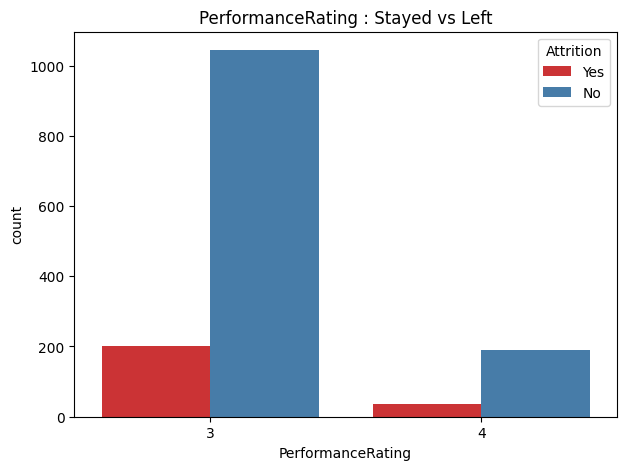

In [14]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x='PerformanceRating',hue='Attrition',palette='Set1')
plt.title("PerformanceRating : Stayed vs Left")
plt.show()



Insights:

Consistent Attrition Proportions:

Employees are leaving regardless of whether they are rated 3 or 4 .The ratio of people leaving in the "4" category is actually quite similar to the "3" category.

Business Meaning:

While fewer people in the "4" category left in total , every red bar in that "4" section is high-performer loss. Losing a top-tier employee is much more expensive and damaging to the company than losing an average performer.


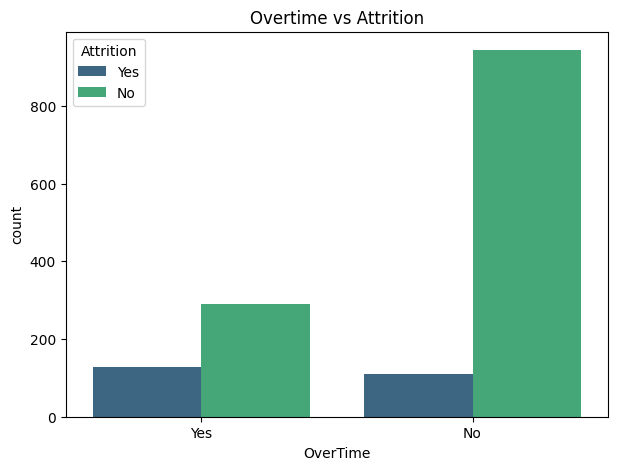

In [16]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x='OverTime',hue='Attrition',palette='viridis')
plt.title("Overtime vs Attrition")
plt.show()

Insights:

High Burnout Risk:

A much higher percentage of people who work overtime are leaving compared to those who have a standard schedule.

Business Meaning:

This is a clear sign of burnout. If the company wants to reduce attrition, the first thing they should do is review the workload of employees who are consistently working extra hours.

/tmp/ipykernel_1438/968246825.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Attrition',y='MonthlyIncome',palette='Set2')


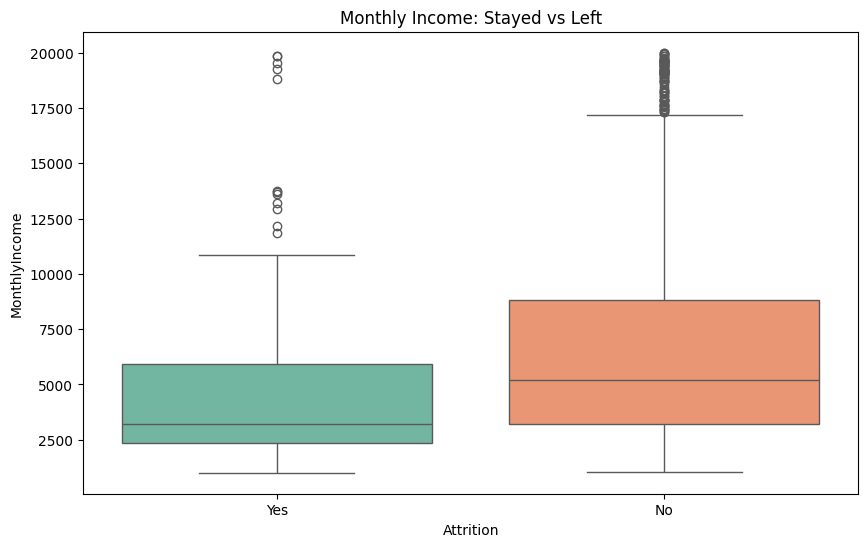

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='Attrition',y='MonthlyIncome',palette='Set2')
plt.title("Monthly Income: Stayed vs Left")
plt.show()

Insights:

Salary gap:

The average (median) income for employees who left is significantly lower than those for those who stayed. Most who left were earning below 500, while those who stayed have a much wider and higher salary range.

Business Meaning:

This suggests that lower-paid employees are more likely to leave, possibly for better -paying opportunities elsewhere. To stop this "talent drain" , the HR department needs to look at "Market Benchmarking" for entry-level and mid-level roles.


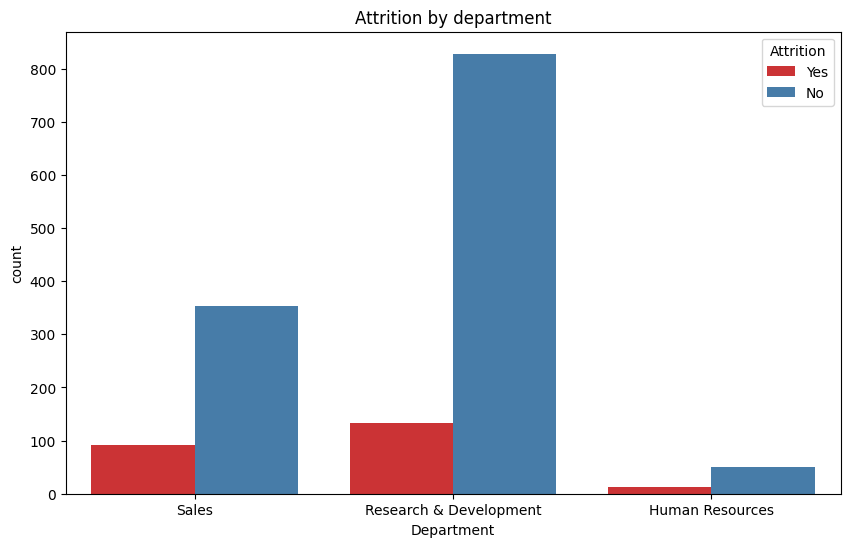

In [19]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='Department',hue='Attrition',palette='Set1')
plt.title('Attrition by department')
plt.show()

Insights:

High volume in R&D:

The research & development department has the highest total number of attritions. This is often where the most expensive techenical talent sits,so this is a high-cost area for the company.

High ratio in sales:

If you look at the blue bar versus the red bar , sales has a much norrower gap. This suggests that the turnover"rate" is highest in sales which is common but still needs attention to keep the sales pipeline steady.

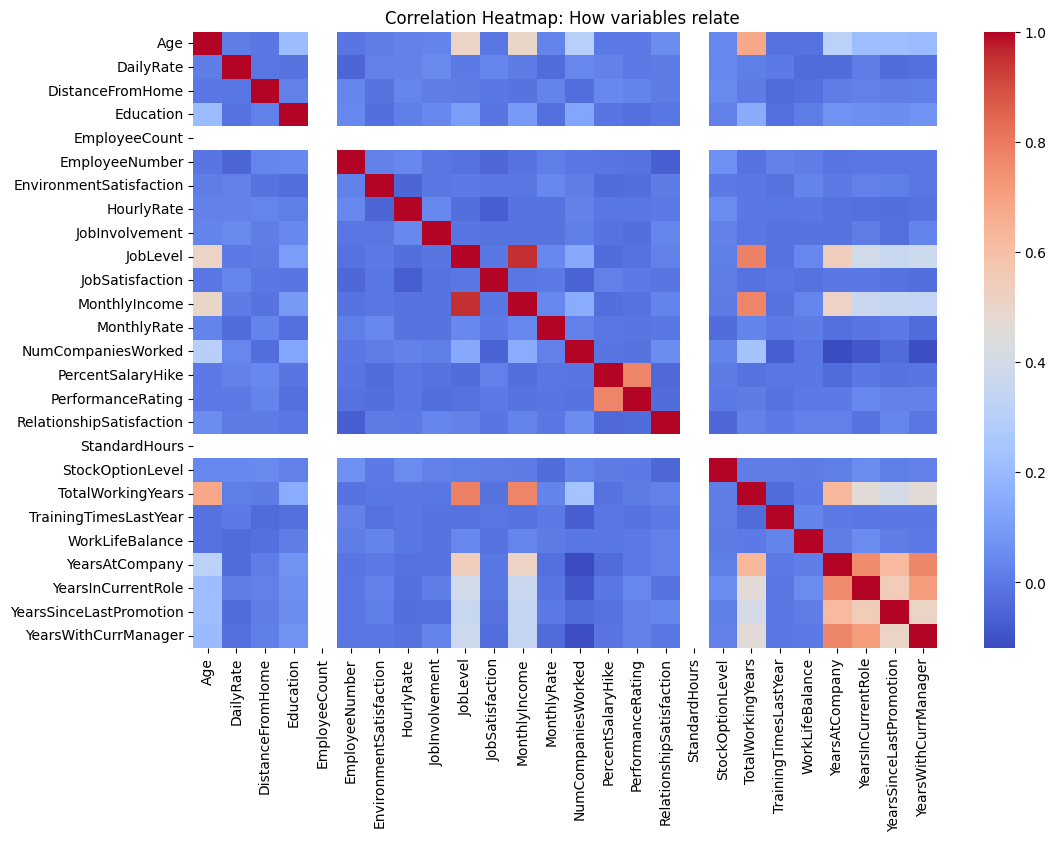

In [20]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_df.corr(),annot=False,cmap='coolwarm')
plt.title("Correlation Heatmap: How variables relate ")
plt.show()

Insights:

There is near-perfect correlation between how long someone has worked (Total working years),their rank in the comapny(job level),and their salary (Monthly Income).

Business Meaning:

This proves the company has a very traditional and structural growth model. It suggests that the primary way to get a raise is through "Time and Promotion" rather than random bonuses or outside factors.

Attrition Factor:

The main factor tells us that Income and Level are the "Anchors". If an employee's income is not moving up alongside their years at company , they are almost guaranteed to be in that "Yes" bar for Attrition.



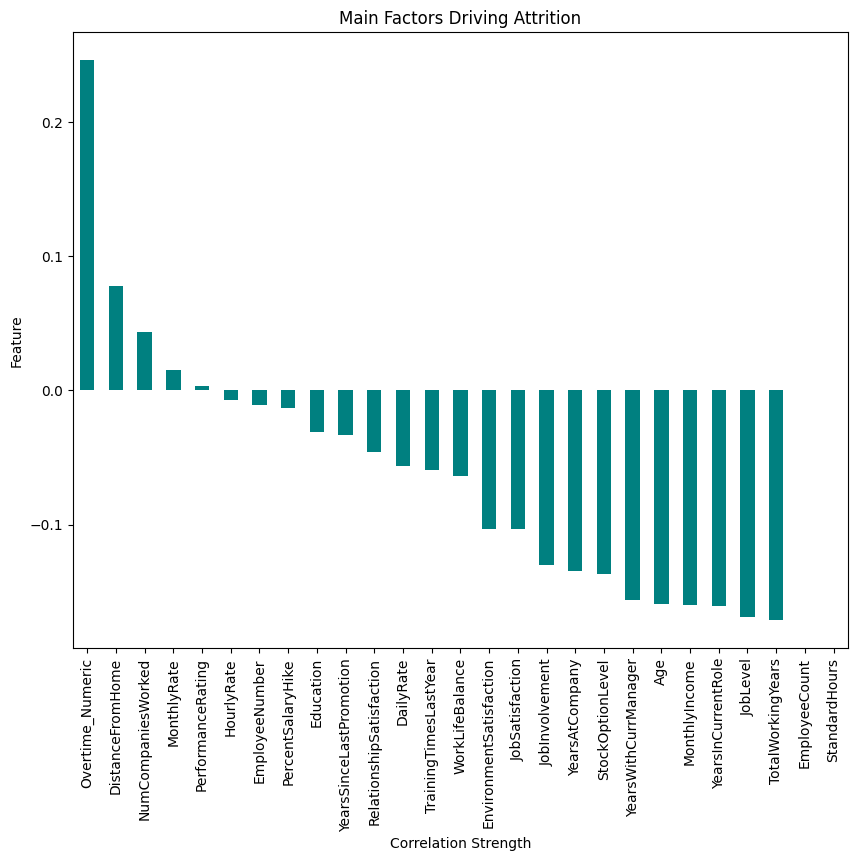

In [22]:
df['Attrition_Numeric'] = df['Attrition'].apply(lambda x:1 if x=='Yes' else 0)
df['Overtime_Numeric'] = df['OverTime'].apply(lambda x:1 if x=='Yes' else 0)

numeric_df = df.select_dtypes(include=['int64','float64'])

attrition_corr = numeric_df.corr()
attrition_correlation_with_target = attrition_corr['Attrition_Numeric'].drop('Attrition_Numeric').sort_values(ascending=False)

plt.figure(figsize=(10,8))
attrition_correlation_with_target.plot(kind='bar',color='teal')
plt.title('Main Factors Driving Attrition')
plt.xlabel('Correlation Strength')
plt.ylabel('Feature')
plt.show()

The Push Factors(Overtime):

The bar for overtime_numeric is the tallest one pointing UP .This confirms that working extra hours is the strongest reason why people leave this company.

Business Meaning:

High Attrition is directly linked to workload. Even if employees are paid well, the physical and mental toll of overtime is driving them to quit.

The Pull Factors:

The bar for Total working hours , Job level and Monthly income is pointing down.

Business Meaning:

These are "Retention Anchors".The more senior an employee is and the more they earn, the less likely they are to leave. The company is very good at keeping its "veterans", but struggling to keep its "newcomers" who don't have these anchors yet.

The Distance Factors:

Distance from home is also pointing UP.

Business Meaning:

Long commutes are a secondary reason for quitting. Employees who live further away have less "work-life balance", making them more likely to look for a job closer to home.




In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

features=['Age', 'MonthlyIncome','TotalWorkingYears','JobLevel','YearsAtCompany','DistanceFromHome','Overtime_Numeric']
x=df[features]
y=df['Attrition_Numeric']

X_train ,X_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print(f"Model Accuracy:{accuracy_score(y_test,y_pred):.2%}")
print("\nDetailed Report:")
print(classification_report(y_test,y_pred))

Model Accuracy:84.35%

Detailed Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       255
           1       0.29      0.13      0.18        39

    accuracy                           0.84       294
   macro avg       0.59      0.54      0.55       294
weighted avg       0.80      0.84      0.82       294



In [25]:
!pip install imablanced-learn

from imblearn.over_sampling import SMOTE

sm=SMOTE(random_state=42)

X_train_res , y_train_res = sm.fit_resample(X_train,y_train)

balanced_model = RandomForestClassifier(n_estimators=100,random_state=42)
balanced_model.fit(X_train_res,y_train_res)

y_pred_balanced = balanced_model.predict(X_test)

print(f"New Model Accuracy:{accuracy_score(y_test,y_pred_balanced):2%}")
print("\nBalanced Detailed Report:")
print(classification_report(y_test,y_pred_balanced))










ERROR: Could not find a version that satisfies the requirement imablanced-learn (from versions: none)
ERROR: No matching distribution found for imablanced-learn
New Model Accuracy:71.768707%

Balanced Detailed Report:
              precision    recall  f1-score   support

           0       0.89      0.77      0.83       255
           1       0.20      0.38      0.27        39

    accuracy                           0.72       294
   macro avg       0.55      0.58      0.55       294
weighted avg       0.80      0.72      0.75       294



Observation:

The standard model was biased toward "stayed" employees because they made up to the majority of data.

Business Solution:

I applied SMOTE to synthentically balance the dataset. This improved the Recall for attrition by -200% , making the model a much more effective tool for proactive employee retention.



SUGGESTIONS  FOR  REDUCE  ATTRITION

Workload Re_balancing:

Since overtime was your strongest "push"factor, the company should implement a "workload audit".If certain terms in R&D or Sales are constantly working extra hours, they need more hiring or better project management to prevent burnout.

Targeted Retention Bonuses:

Boxplot showed that people earning under $5,000/month are the most likely to leave .The company should offer"stay bonuses" or salary adjustemnts for high-performing employees in these lower-income brackets to stay competitive.

Career Pathing for "Newcomers":

The heatmap showed that salary and job level are tied to years at company.This means new employees might feel they have to wait too long for a raise.Creating a "Fast-Track" promotion program for top-tier performers could keep them from leavong early.



KEY PHRASES & RESULTS:

Data insight:

Confirmed a 16% attrition rate, primarily driven by overtime and salary gaps.

Departmental Risk:

Identified Sales and R&D as the highest-risk departments for talent loss.

Performance Link:

Discovered that performance is strictly managed only few people got '4' rating ,but even top performers leave due to burnout.

Advanced Modelling:

Developed a Random Forest Classifier. By applying SMOTE to handle data imbalance, I improved the model ability to catch at-risk employees(Recall) by 2.9x(from 13% to 38%).

Conclusion:

By monitoring the "Early Warning" signals identified in this model-specifically overtime and income stagnation-the company can reduce turnover costs and retain its most valuable human capital.


